In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Imports

In [ ]:
!pip install -U monai


In [ ]:
!pip install -U monai[all]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset
import torch.nn as nn
import time
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, jaccard_score,balanced_accuracy_score
from monai.losses import TverskyLoss,DiceLoss, GeneralizedDiceFocalLoss, GeneralizedDiceLoss
import csv
import torch
import torch.nn.functional as F
import os
from PIL import Image
import numpy as np
import random

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [ ]:
print(torch.__version__)
print(torch.cuda.is_available())



2.10.0+cu128
True


#### Import Data

In [ ]:
imagem_dir = [
    "/content/drive/MyDrive/imagem_1_teste",
    "/content/drive/MyDrive/imagem_2_teste"
]


In [ ]:
mascara_dir = [
    "/content/drive/MyDrive/label_1_teste",
    "/content/drive/MyDrive/label_2_teste"
]

#### Load Data

In [ ]:
def load_data(imagem_dir, mascara_dir, target_size):
    images = []
    masks = []

    for imagem_dir, mascara_dir in zip(imagem_dir, mascara_dir):
        image_files = sorted([f for f in os.listdir(imagem_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.JPG', '.JPEG'))])
        mask_files = sorted([f for f in os.listdir(mascara_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg','.JPG', '.JPEG'))])

        if len(image_files) != len(mask_files):
          raise ValueError("Nº de imagens e máscaras não corresponde!")


        for img_file, mask_file in zip(image_files, mask_files):
        # --- Imagem ---
          img_path  = os.path.join(imagem_dir, img_file)
          image     = Image.open(img_path).convert("RGB")
          image     = image.resize(target_size)
          image_np  = np.array(image, dtype=np.float32) /255.0            # (H, W, 3)

        # --- Máscara (preto/branco) ---
          mask_path = os.path.join(mascara_dir, mask_file)
          mask      = Image.open(mask_path).convert("L")   # escala de cinzentos
          mask      = mask.resize(target_size, resample=Image.NEAREST)

          mask_np   = np.array(mask)
          print(f"\n {mask_file}")
          print("Unique antes do binário:", np.unique(mask_np)[:10])
        # tudo o que for > 0 conta como classe 1 (branco)
          mask_bin  = (mask_np > 0).astype(np.uint8)
          print("Unique depois do binário:", np.unique(mask_bin))

          mask_bin  = np.expand_dims(mask_bin, axis=-1)    # (H, W, 1)

          images.append(image_np)
          masks.append(mask_bin)

    images = np.array(images)
    masks  = np.array(masks)

    print("\n🧩 Unique global em Y (todas as máscaras):", np.unique(masks))

    if images.shape[0] != masks.shape[0]:
        raise ValueError("Nº inconsistente de imagens e máscaras!")

    return images, masks


In [ ]:
X, y = load_data(imagem_dir, mascara_dir, target_size=(256, 256))
print(f"Imagens carregadas: {len(X)}")
print(f"Máscaras carregadas: {len(y)}")


 image_1.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_10.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_100.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_11.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_12.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_13.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_14.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_15.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_16.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_17.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_18.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_19.png
Unique antes do binário: [  0 255]
Unique depois do binário: [0 1]

 image_2.png
Un

In [ ]:
print(y[4])

In [ ]:
np.set_printoptions(threshold=np.inf)  # mostra o array inteiro
print(y[1].squeeze())

In [ ]:
value_to_color = {
    0: (0, 0, 0),      # Preto
    1: (255, 255, 255),  # Branco
}

def decode_mask(mask):
    h, w = mask.shape[:2]
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for value, color in value_to_color.items():
        rgb_mask[mask.squeeze() == value] = color

    return rgb_mask

def show_batch(images, masks, batch_size=4):
    plt.figure(figsize=(12, batch_size * 3))

    for i in range(batch_size):
        if i >= len(images):
            break

        plt.subplot(batch_size, 2, 2*i + 1)
        plt.imshow(images[i])
        plt.title("Imagem")
        plt.axis("off")

        plt.subplot(batch_size, 2, 2*i + 2)
        colored_mask = decode_mask(masks[i])
        plt.imshow(colored_mask)
        plt.title("Máscara")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


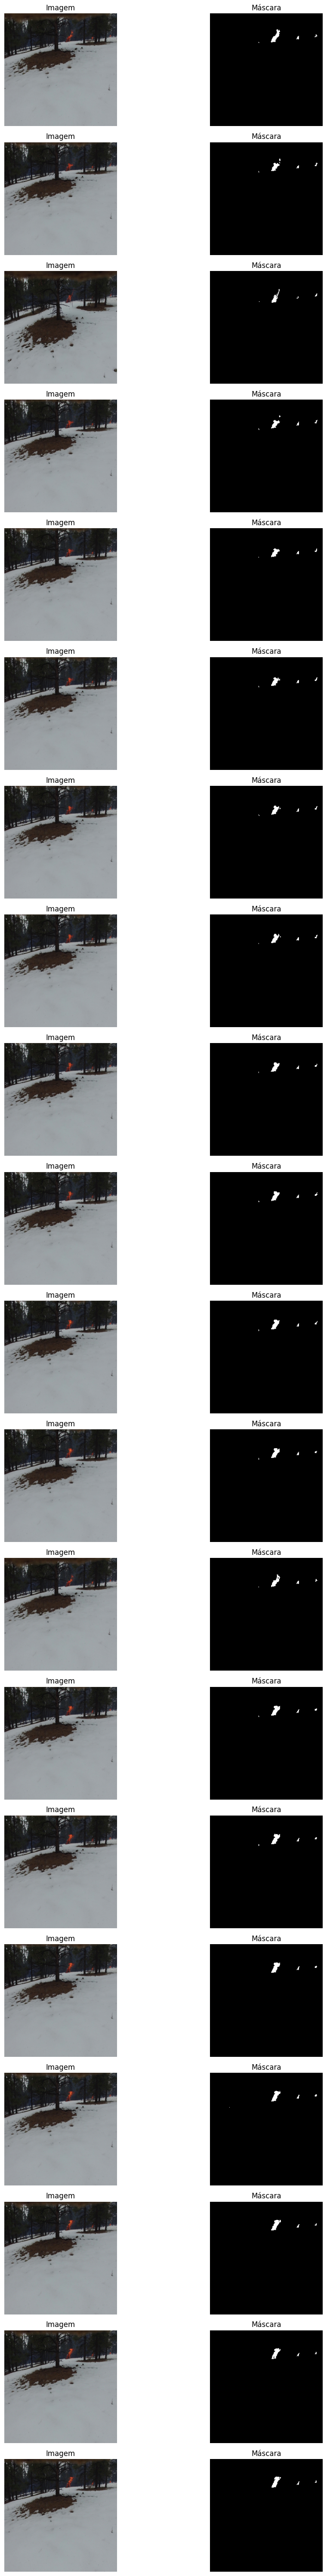

In [ ]:
show_batch(X, y, batch_size=20)


#### Transform to tensors

In [ ]:
X_tensor = torch.tensor(X, dtype=torch.float32)  # Imagens
y_tensor = torch.tensor(y, dtype=torch.float32)  # Máscaras

In [ ]:
print(y_tensor[1].unique())

tensor([0., 1.])


In [ ]:
X_tensor.shape

torch.Size([200, 256, 256, 3])

In [ ]:
X_tensor.permute(0, 3, 1, 2)

In [ ]:
y_tensor.shape

torch.Size([200, 256, 256, 1])

In [ ]:
y_tensor.squeeze(-1).long()

In [ ]:
y_tensor.shape

torch.Size([200, 256, 256, 1])

In [ ]:
vals, counts = np.unique(y_tensor.numpy().astype(int), return_counts=True)
print(dict(zip(vals, counts)))

{np.int64(0): np.int64(12165005), np.int64(1): np.int64(942195)}


#### Todal Dataloader

In [ ]:
X_tensorcopy = X_tensor
y_tensorcopy = y_tensor

In [ ]:
X_tensorcopy = X_tensor.permute(0, 3, 1, 2)
y_tensorcopy = y_tensor.permute(0, 3, 1, 2)

In [ ]:
total_dataset = TensorDataset(X_tensorcopy, y_tensorcopy)

In [ ]:
total_loader = DataLoader(total_dataset, batch_size=8)

In [ ]:
for images, labels in total_loader:
    print("Formato das imagens:", images.shape)
    print("Formato das máscaras:", labels.shape)  #(B, H, W)
    break

Formato das imagens: torch.Size([8, 3, 256, 256])
Formato das máscaras: torch.Size([8, 1, 256, 256])


In [ ]:
def compute_pixel_statistics(loader):
    total_pixels = 0
    fire_pixels = 0

    for _, labels in loader:
        labels = labels.numpy()
        total_pixels += labels.size
        fire_pixels += (labels == 1).sum()

    background_pixels = total_pixels - fire_pixels

    print("Total pixels:", total_pixels)
    print("Fire pixels:", fire_pixels)
    print("Background pixels:", background_pixels)
    print("Fire %:", fire_pixels / total_pixels)
    print("Background %:", background_pixels / total_pixels)

In [ ]:
compute_pixel_statistics(total_loader)

Total pixels: 13107200
Fire pixels: 942195
Background pixels: 12165005
Fire %: 0.07188377380371094
Background %: 0.9281162261962891


#### Split Data

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.25, random_state=42)

print("Tamanho do conjunto de treino:", X_train.shape)
print("Tamanho do conjunto de validação:", X_val.shape)

Tamanho do conjunto de treino: torch.Size([150, 256, 256, 3])
Tamanho do conjunto de validação: torch.Size([50, 256, 256, 3])


#### Create a Split DataLoader

In [ ]:
train_dataset = TensorDataset(
    X_train.permute(0, 3, 1, 2),
    y_train.permute(0, 3, 1, 2))

val_dataset = TensorDataset(
    X_val.permute(0, 3, 1, 2),
    y_val.permute(0, 3, 1, 2))


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [ ]:
for images, labels in train_loader:
    print("Formato das imagens:", images.shape)    # Ex: (B, C, H, W)
    print("Formato das máscaras:", labels.shape)   # Ex: (B, H, W)

    image = images[0]  # (C, H, W)
    label = labels[0]  # (H, W)

    image_np = image.numpy()
    label_np = label.numpy()

    print("Imagem (valores do canal 0):")
    print(image_np[0])

    print("\nMáscara (rótulos por pixel):")
    print(label_np)

    break


### Funções de metricas

In [ ]:
def evaluate_model_metrics(model, val_loader, device):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            predictions = outputs.argmax(dim=1)

            labels = labels.squeeze(1).long().flatten().cpu().numpy()
            predictions = predictions.flatten().cpu().numpy()

            all_labels.append(labels)
            all_predictions.append(predictions)

    all_labels = np.concatenate(all_labels)
    all_predictions = np.concatenate(all_predictions)

    accuracy = accuracy_score(all_labels, all_predictions)
    balanced_acc = balanced_accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='binary', pos_label=1, zero_division=0)
    jaccard = jaccard_score(all_labels, all_predictions, average='binary', pos_label=1, zero_division=0)


    print(f"  Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Balanced Accuracy: {balanced_acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Jaccard Index (IoU): {jaccard:.4f}")

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "f1_score": f1,
        "jaccard_index": jaccard
    }

#### Loss Functions

In [ ]:
def get_loss_function(loss_name):
    if loss_name == "CrossEntropy":
        return nn.CrossEntropyLoss()
    elif loss_name == "Dice":
        return DiceLoss(to_onehot_y=True, softmax=True)
    elif loss_name == "Jaccard":
        return GeneralizedDiceFocalLoss(to_onehot_y=True, softmax=True)
    elif loss_name == "Tversky":
        return TverskyLoss(to_onehot_y=True,alpha=0.3 , beta=0.7,softmax=True)
    elif loss_name == "GeneralizedDice":
        return GeneralizedDiceLoss(to_onehot_y=True, softmax=True)
    else:
        raise ValueError("Loss não reconhecida!")

#### Model Resunet-a - ORIGINAL

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=dilation, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=dilation, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)

class ResUNetA(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()

        # Encoder com dilated convolutions
        self.enc1 = ResidualBlock(in_channels, 64, stride=1, dilation=1)
        self.enc2 = ResidualBlock(64, 128, stride=2, dilation=2)
        self.enc3 = ResidualBlock(128, 256, stride=2, dilation=4)
        self.enc4 = ResidualBlock(256, 512, stride=2, dilation=8)

        # Bottleneck
        self.bottleneck = ResidualBlock(512, 1024, stride=1, dilation=1)

        # Decoder com upsampling + residual blocks
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = ResidualBlock(512, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = ResidualBlock(256, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ResidualBlock(128, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ResidualBlock(64, 64)

        # Final output layer
        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Bottleneck
        b = self.bottleneck(e4)

        # Decoder (corrigido com F.interpolate para garantir o mesmo tamanho nas somas)
        u4 = self.up4(b)
        u4 = F.interpolate(u4, size=e4.shape[2:], mode='bilinear', align_corners=False)
        d4 = self.dec4(u4 + e4)

        u3 = self.up3(d4)
        u3 = F.interpolate(u3, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d3 = self.dec3(u3 + e3)

        u2 = self.up2(d3)
        u2 = F.interpolate(u2, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d2 = self.dec2(u2 + e2)

        u1 = self.up1(d2)
        u1 = F.interpolate(u1, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d1 = self.dec1(u1 + e1)

        out = self.final(d1)
        return out


In [ ]:
def plot_metrics1(train_losses, val_losses, train_accuracies, val_accuracies,
                  val_balanced_acc, val_f1s, val_jaccards, loss_name, lr, architecture_name):

    n = len(train_losses)
    if not all(len(lst) == n for lst in [val_losses, train_accuracies, val_accuracies, val_balanced_acc, val_f1s, val_jaccards]):
        raise ValueError("As listas de métricas não têm todas o mesmo comprimento.")

    epochs = list(range(1, n + 1))

    save_dir = os.path.join("improvement_metricas", architecture_name)
    os.makedirs(save_dir, exist_ok=True)

    identifier = f"{architecture_name}_{loss_name}_lr_{str(lr).replace('.', '_')}"

    # Guardar CSV
    csv_filename = os.path.join(save_dir, f"metrics_{identifier}.csv")
    with open(csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([
            "Epoch", "Train Loss", "Val Loss", "Train Accuracy",
            "Validation Accuracy", "Balanced Accuracy", "F1 Score", "Jaccard Index"
        ])
        for i in range(n):
            writer.writerow([
                epochs[i], train_losses[i], val_losses[i],
                train_accuracies[i], val_accuracies[i],
                val_balanced_acc[i], val_f1s[i], val_jaccards[i]
            ])

    print(f"CSV saved: {csv_filename}")

    # Gráfico de Loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Train Loss", color="red")
    plt.plot(epochs, val_losses, label="Validation Loss", color="orange", linestyle="--")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.title(f"Training & Validation Loss per Epoch ({loss_name}, LR={lr})")
    plt.savefig(os.path.join(save_dir, f"resunet_loss_plot_{identifier}.png"))
    plt.show()
    plt.close()

    # Gráfico de Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_accuracies, label="Train Accuracy", color="blue")
    plt.plot(epochs, val_accuracies, label="Validation Accuracy", color="green", linestyle="dashed", marker="o")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.title(f"Train and Validation Accuracy per Epoch ({loss_name}, LR={lr})")
    plt.savefig(os.path.join(save_dir, f"resunet_accuracy_plot_{identifier}.png"))
    plt.show()
    plt.close()

    # Gráfico de métricas
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, val_f1s, label="F1 Score", marker="x")
    plt.plot(epochs, val_balanced_acc, label="Balanced Accuracy", marker="d")
    plt.plot(epochs, val_jaccards, label="Jaccard Index", marker="s")
    plt.xlabel("Epochs")
    plt.ylabel("Metric Score")
    plt.legend()
    plt.grid()
    plt.title(f"Validation Metrics per Epoch ({loss_name}, LR={lr})")
    plt.savefig(os.path.join(save_dir, f"resunet_metrics_plot_{identifier}.png"))
    plt.show()
    plt.close()

In [ ]:
def train_model_with_varied_losses(train_loader, val_loader, total_loader, device, num_epochs=50, save_interval=10):
    loss_functions = ["GeneralizedDice"]
    learning_rates = [0.01, 0.001, 0.0001]

    results = {}

    for loss_name in loss_functions:
        results[loss_name] = {}

        for lr in learning_rates:
            print(f"\nTreinando com Loss: {loss_name} | Learning Rate: {lr}\n")

            # REINICIAR O MODELO PARA CADA LEARNING RATE
            model = ResUNetA(in_channels=3, num_classes=2).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            loss_function = get_loss_function(loss_name)

            train_losses, val_losses = [], []
            train_accuracies = []
            val_accuracies, val_balanced_acc, val_f1s, val_jaccards = [], [], [], []

            total_start_time = time.time()

            for epoch in range(num_epochs):
                epoch_start_time = time.time()
                model.train()
                running_loss = 0.0
                running_accuracy = 0.0

                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)

                    # Para a loss MONAI, manter labels no formato original
                    loss = loss_function(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item()

                    # Para accuracy, alinhar shape com as previsões
                    preds = outputs.argmax(dim=1)
                    labels_for_metrics = labels.squeeze(1).long()

                    accuracy = accuracy_score(
                        labels_for_metrics.cpu().numpy().flatten(),
                        preds.cpu().numpy().flatten()
                    )
                    running_accuracy += accuracy

                epoch_loss = running_loss / len(train_loader)
                epoch_accuracy = running_accuracy / len(train_loader)

                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_accuracy)

                # Validação
                model.eval()
                val_running_loss = 0.0

                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)

                        outputs = model(inputs)
                        val_loss = loss_function(outputs, labels)
                        val_running_loss += val_loss.item()

                val_loss = val_running_loss / len(val_loader)
                val_losses.append(val_loss)

                metrics = evaluate_model_metrics(model, val_loader, device)
                val_accuracies.append(metrics["accuracy"])
                val_balanced_acc.append(metrics["balanced_accuracy"])
                val_f1s.append(metrics["f1_score"])
                val_jaccards.append(metrics["jaccard_index"])

                if (epoch + 1) % save_interval == 0:
                    torch.save(model.state_dict(), f"resunet_{loss_name}_lr{lr}_epoch{epoch+1}.pth")

                epoch_time = time.time() - epoch_start_time
                print(
                    f"Epoch {epoch+1}/{num_epochs} - "
                    f"Loss: {epoch_loss:.4f} - "
                    f"Val Loss: {val_loss:.4f} - "
                    f"Accuracy: {epoch_accuracy:.4f} - "
                    f"Time: {epoch_time:.2f}s"
                )

            total_time = time.time() - total_start_time
            print(f"Treino concluído para Loss: {loss_name} | LR: {lr} em {total_time // 60:.0f}m {total_time % 60:.0f}s\n")
            print(f"\nMétricas globais do Dataset Inteiro: ")
            final_global_metrics = evaluate_model_metrics(model, total_loader, device)

            plot_metrics1(
                train_losses,
                val_losses,
                train_accuracies,
                val_accuracies,
                val_balanced_acc,
                val_f1s,
                val_jaccards,
                loss_name,
                lr,
                "ResUNetA"
            )

            results[loss_name][lr] = {
                "model": model,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_accuracies": train_accuracies,
                "val_accuracies": val_accuracies,
                "val_balanced_acc": val_balanced_acc,
                "val_f1s": val_f1s,
                "val_jaccards": val_jaccards,
                "global_metrics": final_global_metrics,
                "total_time": total_time

            }

    return results


Treinando com Loss: GeneralizedDice | Learning Rate: 0.01

  Metrics:
  Accuracy: 0.8805
  Balanced Accuracy: 0.7920
  F1 Score: 0.4440
  Jaccard Index (IoU): 0.2853
Epoch 1/10 - Loss: 0.4156 - Val Loss: 0.6748 - Accuracy: 0.9305 - Time: 14.45s
  Metrics:
  Accuracy: 0.9561
  Balanced Accuracy: 0.7436
  F1 Score: 0.6105
  Jaccard Index (IoU): 0.4394
Epoch 2/10 - Loss: 0.2485 - Val Loss: 0.5035 - Accuracy: 0.9663 - Time: 13.05s
  Metrics:
  Accuracy: 0.9789
  Balanced Accuracy: 0.9174
  F1 Score: 0.8473
  Jaccard Index (IoU): 0.7350
Epoch 3/10 - Loss: 0.2085 - Val Loss: 0.1577 - Accuracy: 0.9720 - Time: 13.24s
  Metrics:
  Accuracy: 0.9816
  Balanced Accuracy: 0.9345
  F1 Score: 0.8690
  Jaccard Index (IoU): 0.7683
Epoch 4/10 - Loss: 0.1686 - Val Loss: 0.1280 - Accuracy: 0.9754 - Time: 13.51s
  Metrics:
  Accuracy: 0.9721
  Balanced Accuracy: 0.9580
  F1 Score: 0.8236
  Jaccard Index (IoU): 0.7000
Epoch 5/10 - Loss: 0.1611 - Val Loss: 0.1621 - Accuracy: 0.9747 - Time: 13.82s
  Metrics:

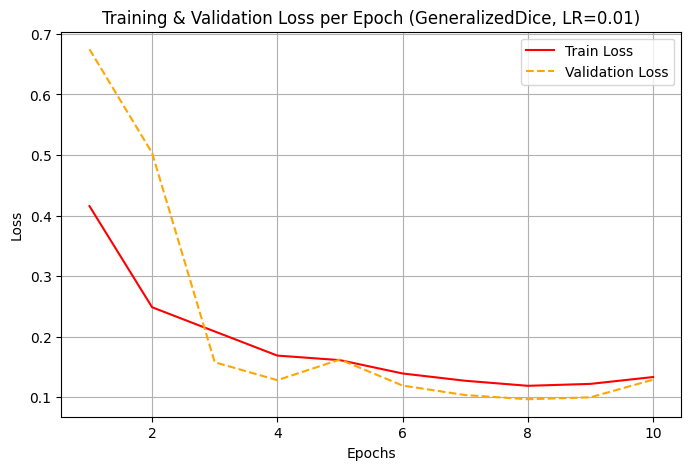

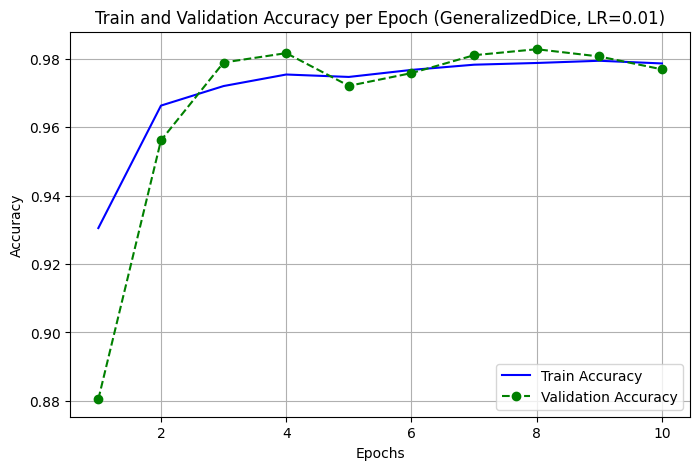

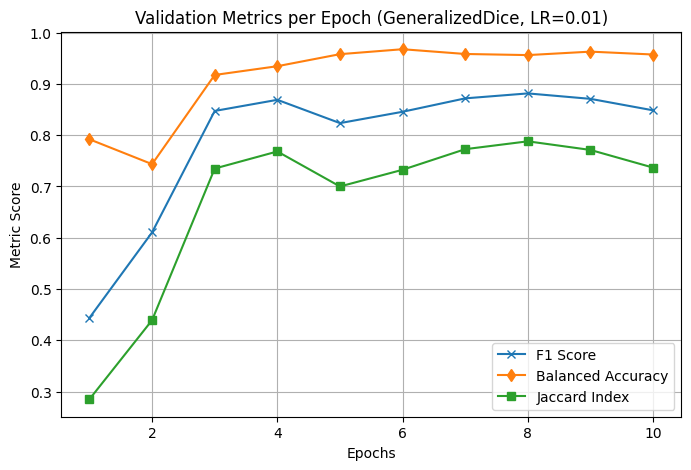


Treinando com Loss: GeneralizedDice | Learning Rate: 0.001

  Metrics:
  Accuracy: 0.9356
  Balanced Accuracy: 0.5354
  F1 Score: 0.1322
  Jaccard Index (IoU): 0.0708
Epoch 1/10 - Loss: 0.3670 - Val Loss: 0.8409 - Accuracy: 0.9308 - Time: 14.99s
  Metrics:
  Accuracy: 0.9762
  Balanced Accuracy: 0.9512
  F1 Score: 0.8430
  Jaccard Index (IoU): 0.7286
Epoch 2/10 - Loss: 0.2062 - Val Loss: 0.1786 - Accuracy: 0.9740 - Time: 15.14s
  Metrics:
  Accuracy: 0.9815
  Balanced Accuracy: 0.9001
  F1 Score: 0.8574
  Jaccard Index (IoU): 0.7504
Epoch 3/10 - Loss: 0.1817 - Val Loss: 0.1375 - Accuracy: 0.9773 - Time: 15.43s
  Metrics:
  Accuracy: 0.9533
  Balanced Accuracy: 0.9365
  F1 Score: 0.7309
  Jaccard Index (IoU): 0.5759
Epoch 4/10 - Loss: 0.1439 - Val Loss: 0.5289 - Accuracy: 0.9754 - Time: 15.41s
  Metrics:
  Accuracy: 0.9836
  Balanced Accuracy: 0.9445
  F1 Score: 0.8835
  Jaccard Index (IoU): 0.7913
Epoch 5/10 - Loss: 0.1421 - Val Loss: 0.1279 - Accuracy: 0.9777 - Time: 15.26s
  Metrics

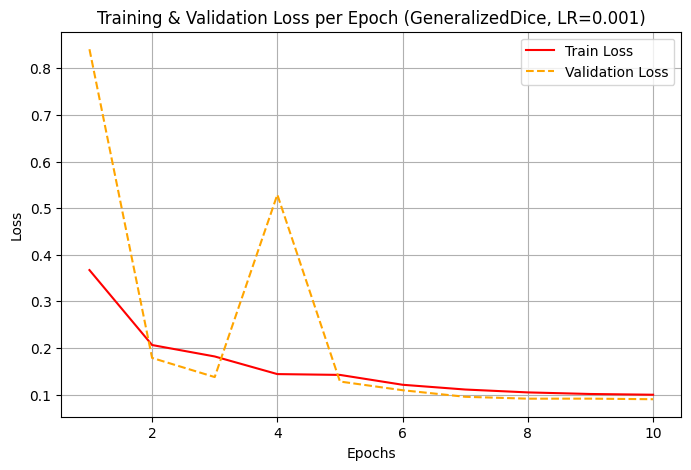

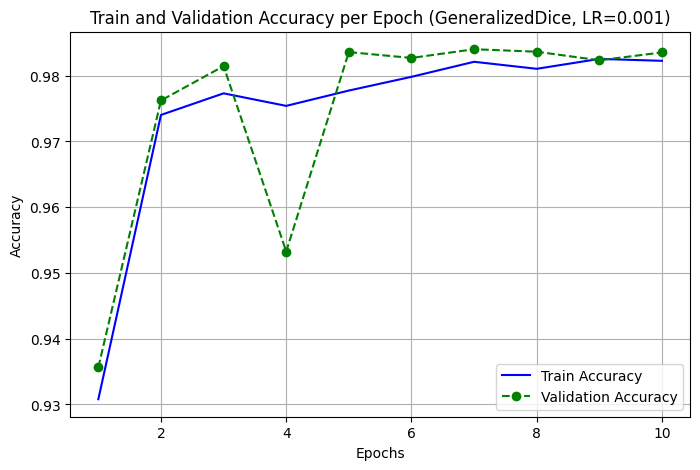

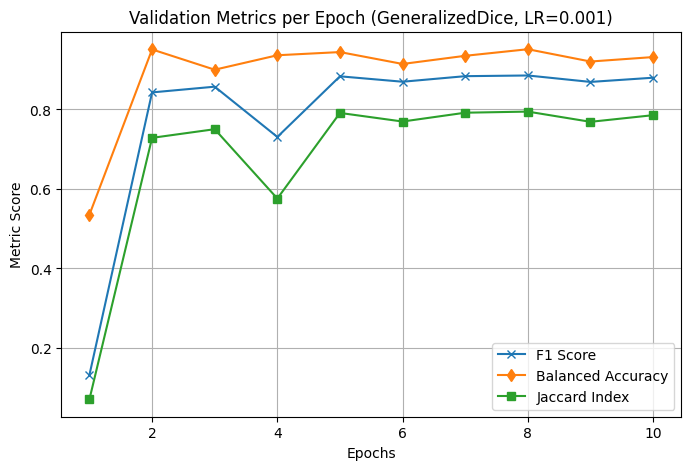


Treinando com Loss: GeneralizedDice | Learning Rate: 0.0001

  Metrics:
  Accuracy: 0.9720
  Balanced Accuracy: 0.8381
  F1 Score: 0.7715
  Jaccard Index (IoU): 0.6280
Epoch 1/10 - Loss: 0.7740 - Val Loss: 0.8386 - Accuracy: 0.7658 - Time: 15.43s
  Metrics:
  Accuracy: 0.9787
  Balanced Accuracy: 0.8626
  F1 Score: 0.8255
  Jaccard Index (IoU): 0.7029
Epoch 2/10 - Loss: 0.5236 - Val Loss: 0.5824 - Accuracy: 0.9748 - Time: 15.45s
  Metrics:
  Accuracy: 0.9813
  Balanced Accuracy: 0.9203
  F1 Score: 0.8630
  Jaccard Index (IoU): 0.7590
Epoch 3/10 - Loss: 0.2166 - Val Loss: 0.2524 - Accuracy: 0.9760 - Time: 15.41s
  Metrics:
  Accuracy: 0.9825
  Balanced Accuracy: 0.9406
  F1 Score: 0.8756
  Jaccard Index (IoU): 0.7788
Epoch 4/10 - Loss: 0.1481 - Val Loss: 0.1377 - Accuracy: 0.9789 - Time: 15.38s
  Metrics:
  Accuracy: 0.9828
  Balanced Accuracy: 0.9384
  F1 Score: 0.8773
  Jaccard Index (IoU): 0.7814
Epoch 5/10 - Loss: 0.1297 - Val Loss: 0.1194 - Accuracy: 0.9815 - Time: 15.38s
  Metric

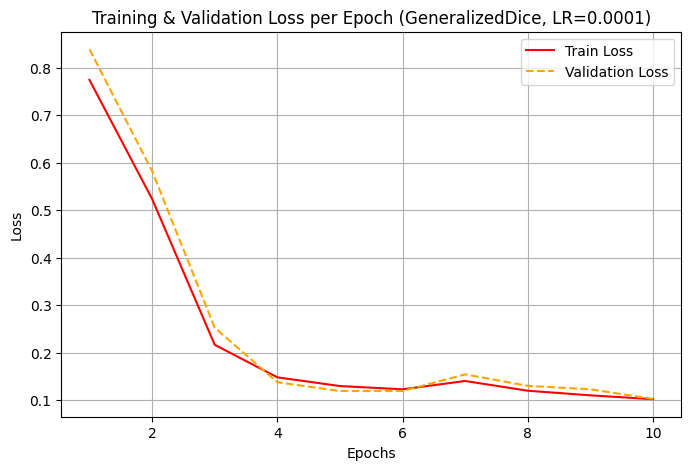

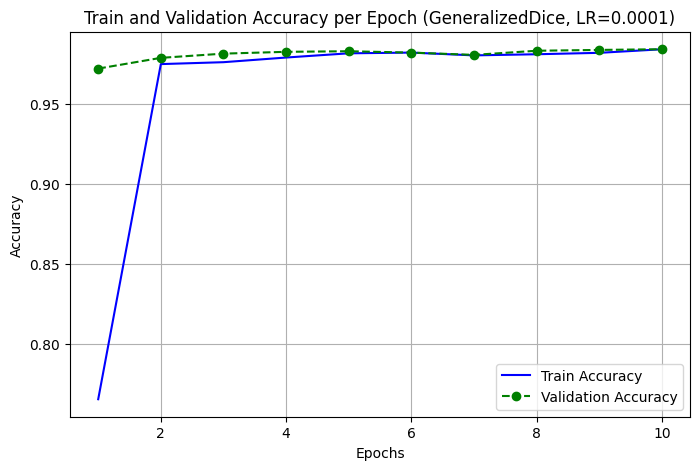

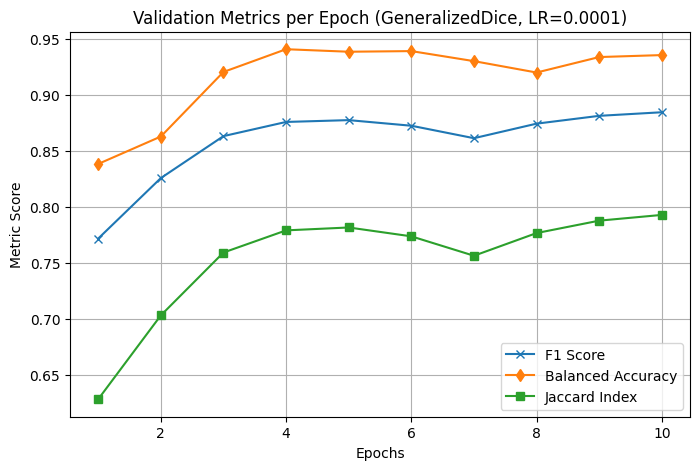

In [ ]:
if __name__ == "__main__":
    num_classes = 2
    model = ResUNetA(num_classes=num_classes)


    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_model_with_varied_losses(train_loader, val_loader, total_loader, device, num_epochs=10, save_interval=10)

| Loss            |     LR | Epochs | Val Loss final | Val Accuracy | Balanced Accuracy |     F1 |    IoU |
| --------------- | -----: | -----: | -------------: | -----------: | ----------------: | -----: | -----: |
| GeneralizedDice |   0.01 |      5 |         0.1285 |       0.9806 |            0.9227 | 0.8590 | 0.7529 |
| GeneralizedDice |  0.001 |      5 |         0.1090 |       0.9824 |            0.9183 | 0.8688 | 0.7681 |
| GeneralizedDice | 0.0001 |      5 |         0.1193 |       0.9818 |            0.9578 | 0.8760 | 0.7793 |


#### Model Resunet-a com Concat

In [ ]:
class ResUNetConcat(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()

        # Encoder
        self.enc1 = ResidualBlock(in_channels, 64, stride=1, dilation=1)
        self.enc2 = ResidualBlock(64, 128, stride=2, dilation=2)
        self.enc3 = ResidualBlock(128, 256, stride=2, dilation=4)
        self.enc4 = ResidualBlock(256, 512, stride=2, dilation=8)

        # Bottleneck
        self.bottleneck = ResidualBlock(512, 1024, stride=1, dilation=1)

        # Decoder (⚠️ canais ajustados por causa do concat)
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = ResidualBlock(512 + 512, 512)  # concat → 1024

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = ResidualBlock(256 + 256, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ResidualBlock(128 + 128, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ResidualBlock(64 + 64, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Bottleneck
        b = self.bottleneck(e4)

        # Decoder com CONCAT
        u4 = self.up4(b)
        u4 = F.interpolate(u4, size=e4.shape[2:], mode='bilinear', align_corners=False)
        d4 = self.dec4(torch.cat([u4, e4], dim=1))

        u3 = self.up3(d4)
        u3 = F.interpolate(u3, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        u2 = F.interpolate(u2, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        u1 = F.interpolate(u1, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.final(d1)

In [ ]:
def train_model_concat(train_loader, val_loader, total_loader, device, num_epochs=50, save_interval=10):
    loss_functions = ["GeneralizedDice"]
    learning_rates = [0.01, 0.001, 0.0001]

    results = {}

    for loss_name in loss_functions:
        results[loss_name] = {}

        for lr in learning_rates:
            print(f"\nTreinando com Loss: {loss_name} | Learning Rate: {lr}\n")

            # REINICIALIZAR O MODELO PARA CADA LEARNING RATE
            model = ResUNetConcat(in_channels=3, num_classes=2).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            loss_function = get_loss_function(loss_name)

            train_losses, val_losses = [], []
            train_accuracies = []
            val_accuracies, val_balanced_acc, val_f1s, val_jaccards = [], [], [], []

            total_start_time = time.time()

            for epoch in range(num_epochs):
                epoch_start_time = time.time()
                model.train()
                running_loss = 0.0
                running_accuracy = 0.0

                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)

                    # Para a loss MONAI, manter labels no formato original
                    loss = loss_function(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item()

                    # Para accuracy, alinhar shape com as previsões
                    preds = outputs.argmax(dim=1)
                    labels_for_metrics = labels.squeeze(1).long()

                    accuracy = accuracy_score(
                        labels_for_metrics.cpu().numpy().flatten(),
                        preds.cpu().numpy().flatten()
                    )
                    running_accuracy += accuracy

                epoch_loss = running_loss / len(train_loader)
                epoch_accuracy = running_accuracy / len(train_loader)

                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_accuracy)

                # Validação
                model.eval()
                val_running_loss = 0.0

                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)

                        outputs = model(inputs)
                        val_loss = loss_function(outputs, labels)
                        val_running_loss += val_loss.item()

                val_loss = val_running_loss / len(val_loader)
                val_losses.append(val_loss)

                metrics = evaluate_model_metrics(model, val_loader, device)
                val_accuracies.append(metrics["accuracy"])
                val_balanced_acc.append(metrics["balanced_accuracy"])
                val_f1s.append(metrics["f1_score"])
                val_jaccards.append(metrics["jaccard_index"])

                if (epoch + 1) % save_interval == 0:
                    torch.save(model.state_dict(), f"resunet_{loss_name}_lr{lr}_epoch{epoch+1}.pth")

                epoch_time = time.time() - epoch_start_time
                print(
                    f"Epoch {epoch+1}/{num_epochs} - "
                    f"Loss: {epoch_loss:.4f} - "
                    f"Val Loss: {val_loss:.4f} - "
                    f"Accuracy: {epoch_accuracy:.4f} - "
                    f"Time: {epoch_time:.2f}s"
                )

            total_time = time.time() - total_start_time
            print(f"Treino concluído para Loss: {loss_name} | LR: {lr} em {total_time // 60:.0f}m {total_time % 60:.0f}s\n")
            print(f"\nMétricas globais do Dataset Inteiro:")
            final_global_metrics = evaluate_model_metrics(model, total_loader, device)

            plot_metrics1(
                train_losses,
                val_losses,
                train_accuracies,
                val_accuracies,
                val_balanced_acc,
                val_f1s,
                val_jaccards,
                loss_name,
                lr,
                "ResUNetConcat"
            )

            results[loss_name][lr] = {
                "model": model,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_accuracies": train_accuracies,
                "val_accuracies": val_accuracies,
                "val_balanced_acc": val_balanced_acc,
                "val_f1s": val_f1s,
                "val_jaccards": val_jaccards,
                "global_metrics": final_global_metrics,
                "total_time": total_time

            }

    return results


Treinando com Loss: GeneralizedDice | Learning Rate: 0.01

  Metrics:
  Accuracy: 0.9526
  Balanced Accuracy: 0.6855
  F1 Score: 0.5229
  Jaccard Index (IoU): 0.3540
Epoch 1/10 - Loss: 0.4457 - Val Loss: 0.6412 - Accuracy: 0.9072 - Time: 1.57s
  Metrics:
  Accuracy: 0.9568
  Balanced Accuracy: 0.7981
  F1 Score: 0.6629
  Jaccard Index (IoU): 0.4958
Epoch 2/10 - Loss: 0.2070 - Val Loss: 0.4920 - Accuracy: 0.9688 - Time: 1.55s
  Metrics:
  Accuracy: 0.9771
  Balanced Accuracy: 0.9252
  F1 Score: 0.8392
  Jaccard Index (IoU): 0.7229
Epoch 3/10 - Loss: 0.1787 - Val Loss: 0.1445 - Accuracy: 0.9707 - Time: 1.54s
  Metrics:
  Accuracy: 0.9772
  Balanced Accuracy: 0.9343
  F1 Score: 0.8431
  Jaccard Index (IoU): 0.7288
Epoch 4/10 - Loss: 0.1624 - Val Loss: 0.1390 - Accuracy: 0.9770 - Time: 1.53s
  Metrics:
  Accuracy: 0.9805
  Balanced Accuracy: 0.9459
  F1 Score: 0.8654
  Jaccard Index (IoU): 0.7628
Epoch 5/10 - Loss: 0.1559 - Val Loss: 0.1438 - Accuracy: 0.9731 - Time: 1.52s
  Metrics:
  Ac

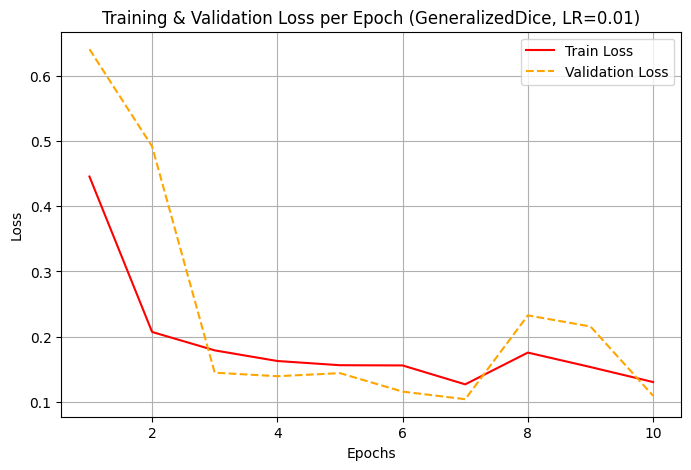

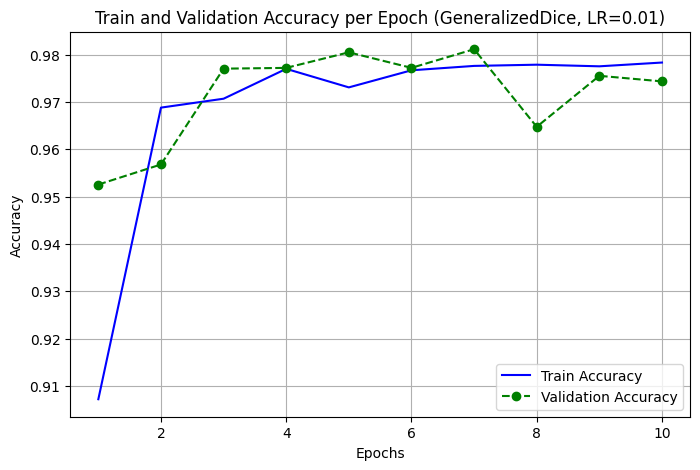

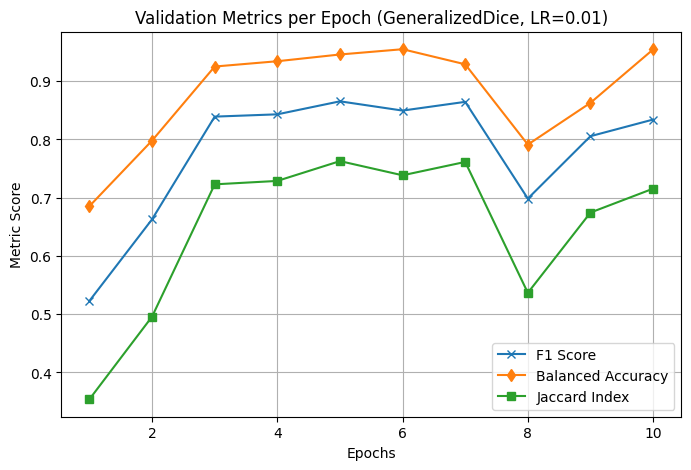


Treinando com Loss: GeneralizedDice | Learning Rate: 0.001

  Metrics:
  Accuracy: 0.9352
  Balanced Accuracy: 0.5354
  F1 Score: 0.1324
  Jaccard Index (IoU): 0.0709
Epoch 1/10 - Loss: 0.6496 - Val Loss: 0.8566 - Accuracy: 0.9362 - Time: 1.51s
  Metrics:
  Accuracy: 0.9795
  Balanced Accuracy: 0.8917
  F1 Score: 0.8418
  Jaccard Index (IoU): 0.7268
Epoch 2/10 - Loss: 0.4321 - Val Loss: 0.4823 - Accuracy: 0.9716 - Time: 1.52s
  Metrics:
  Accuracy: 0.9798
  Balanced Accuracy: 0.9439
  F1 Score: 0.8606
  Jaccard Index (IoU): 0.7553
Epoch 3/10 - Loss: 0.2060 - Val Loss: 0.1510 - Accuracy: 0.9763 - Time: 1.51s
  Metrics:
  Accuracy: 0.9748
  Balanced Accuracy: 0.9576
  F1 Score: 0.8373
  Jaccard Index (IoU): 0.7201
Epoch 4/10 - Loss: 0.1758 - Val Loss: 0.1509 - Accuracy: 0.9760 - Time: 1.51s
  Metrics:
  Accuracy: 0.9828
  Balanced Accuracy: 0.9399
  F1 Score: 0.8773
  Jaccard Index (IoU): 0.7814
Epoch 5/10 - Loss: 0.1601 - Val Loss: 0.1314 - Accuracy: 0.9750 - Time: 1.51s
  Metrics:
  A

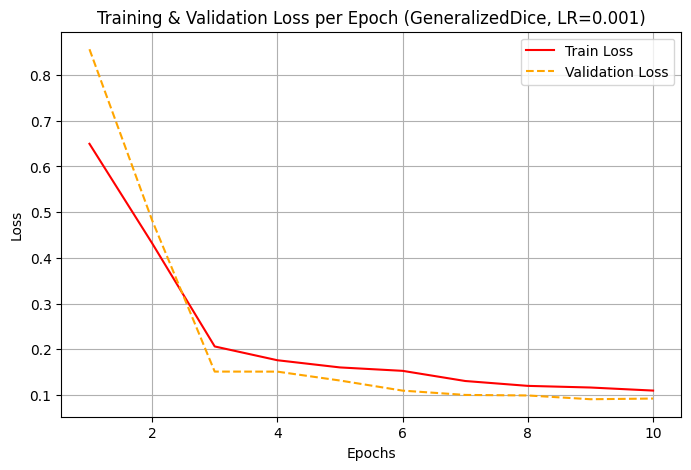

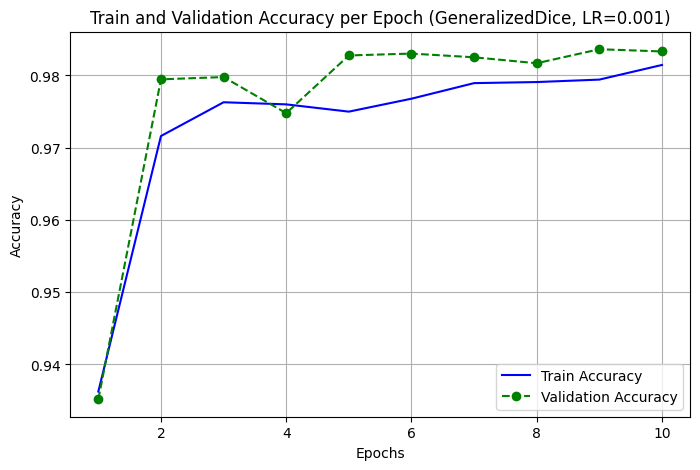

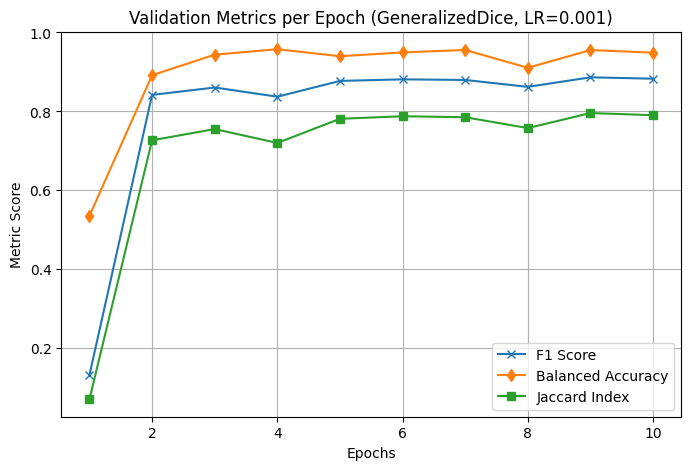


Treinando com Loss: GeneralizedDice | Learning Rate: 0.0001

  Metrics:
  Accuracy: 0.9105
  Balanced Accuracy: 0.8867
  F1 Score: 0.5705
  Jaccard Index (IoU): 0.3991
Epoch 1/10 - Loss: 0.7522 - Val Loss: 0.8450 - Accuracy: 0.9220 - Time: 1.53s
  Metrics:
  Accuracy: 0.4504
  Balanced Accuracy: 0.5635
  F1 Score: 0.1489
  Jaccard Index (IoU): 0.0805
Epoch 2/10 - Loss: 0.6359 - Val Loss: 0.7049 - Accuracy: 0.8518 - Time: 1.51s
  Metrics:
  Accuracy: 0.4561
  Balanced Accuracy: 0.6652
  F1 Score: 0.1877
  Jaccard Index (IoU): 0.1036
Epoch 3/10 - Loss: 0.5961 - Val Loss: 0.6216 - Accuracy: 0.7152 - Time: 1.50s
  Metrics:
  Accuracy: 0.6658
  Balanced Accuracy: 0.7959
  F1 Score: 0.2817
  Jaccard Index (IoU): 0.1640
Epoch 4/10 - Loss: 0.5885 - Val Loss: 0.6092 - Accuracy: 0.7307 - Time: 1.51s
  Metrics:
  Accuracy: 0.7068
  Balanced Accuracy: 0.8149
  F1 Score: 0.3075
  Jaccard Index (IoU): 0.1817
Epoch 5/10 - Loss: 0.5735 - Val Loss: 0.5971 - Accuracy: 0.7535 - Time: 1.51s
  Metrics:
  

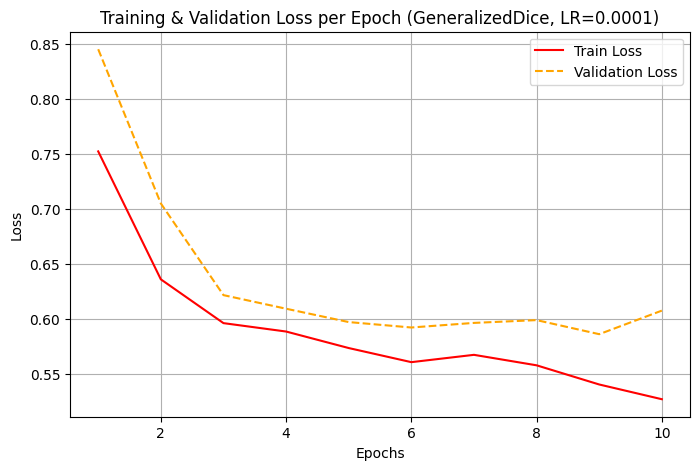

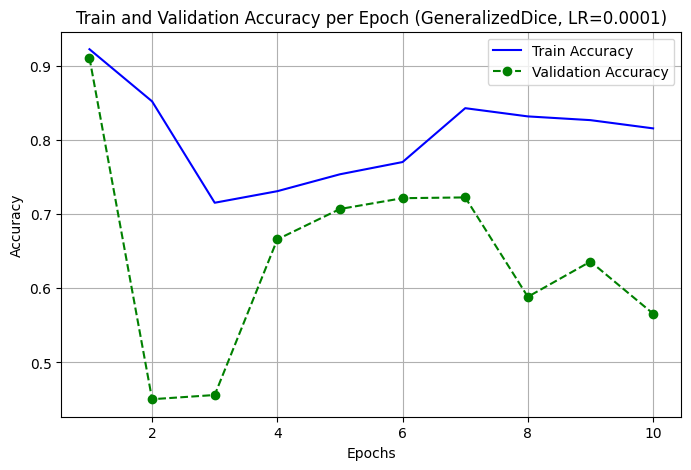

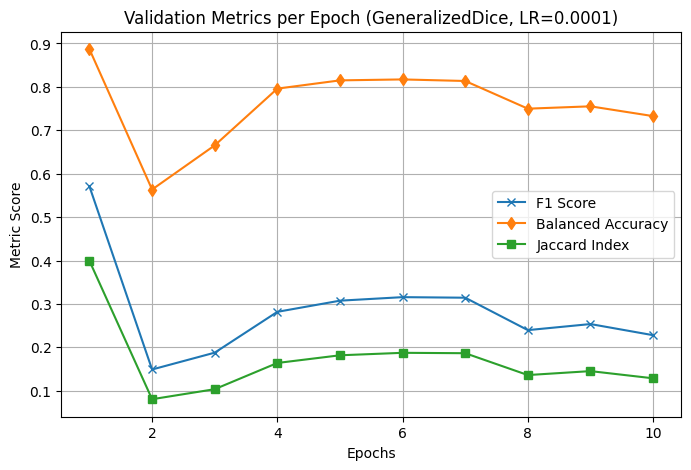

In [ ]:
if __name__ == "__main__":
    num_classes = 2
    model = ResUNetConcat(num_classes=num_classes)


    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_model_concat(train_loader, val_loader, total_loader, device, num_epochs=10, save_interval=10)

| Loss            | LR     | Epochs | Val Loss final | Val Accuracy | Balanced Accuracy | F1     | IoU    |
| --------------- | ------ | ------ | -------------- | ------------ | ----------------- | ------ | ------ |
| GeneralizedDice | 0.01   | 5      | 0.2110         | 0.9692       | 0.9631            | 0.7129 | 0.5538 |
| GeneralizedDice | 0.001  | 5      | 0.1167         | 0.9781       | 0.9455            | 0.8621 | 0.7577 |
| GeneralizedDice | 0.0001 | 5      | 0.5270         | 0.9782       | 0.9697            | 0.8534 | 0.7442 |
